<a href="https://colab.research.google.com/github/L-jsA/AULAS-GEN---GIT/blob/main/atividadegenpaper1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df_insumos = pd.read_json('/content/dados_insumos.json')
df_maquinas = pd.read_json('/content/dados_maquinas.json')
df_turnos = pd.read_json('/content/dados_turnos.json')
df_balanca = pd.read_json('/content/dados_balanca.json')
df_contabilidade = pd.read_json('/content/dados_contabilidade.json')
df_fornecedores = pd.read_json('/content/dados_fornecedores_quimicos.json')

In [ ]:
df_maquinas.columns
df_maquinas.info()
df_maquinas.head()
display(df_maquinas)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         3 non-null      int64 
 1   nome       3 non-null      object
 2   setor      3 non-null      object
 3   status     3 non-null      object
 4   gps        3 non-null      object
 5   dados      3 non-null      object
 6   alerta     1 non-null      object
 7   historico  3 non-null      object
dtypes: int64(1), object(7)
memory usage: 324.0+ bytes


,id,nome,setor,status,gps,dados,alerta,historico
0,1,MP-01: Picador,Pátio,ok,RJ,"[{'k': 'RPM', 'v': '1200'}]",None,"[{'data': '2025-07-01', 'producao': 450, 'temp..."
1,2,MP-02: Digestor,Químico,warn,SC,"[{'k': 'Pressão', 'v': '8.8 bar'}]",Pressão Crítica,"[{'data': '2025-07-01', 'producao': 320, 'temp..."
2,3,MP-03: Secagem,Acabamento,ok,BA,"[{'k': 'Velocidade', 'v': '1100'}]",None,"[{'data': '2025-10-05', 'producao': 300, 'temp..."


In [ ]:
df_turnos.info()
df_turnos.head()
display(df_turnos)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   data    12 non-null     object
 1   turno   12 non-null     object
 2   maq     12 non-null     int64 
 3   op      12 non-null     object
 4   obs     12 non-null     object
dtypes: int64(1), object(4)
memory usage: 612.0+ bytes


,data,turno,maq,op,obs
0,10/01,Manhã,3,Carlos L.,OK
1,10/01,Tarde,2,Mariana S.,Falha Pressão
2,12/02,Manhã,3,João P.,OK
3,12/02,Noite,1,Renata M.,Parada Não Planejada
4,15/03,Manhã,3,Carlos L.,OK
5,15/03,Tarde,3,Mariana S.,OK
6,18/04,Manhã,2,João P.,Manutenção
7,18/04,Noite,2,Renata M.,OK
8,20/05,Manhã,3,Carlos L.,OK
9,20/05,Tarde,2,Mariana S.,Vibração Excessiva


In [ ]:
df_insumos.info()
df_insumos.head()
display(df_insumos)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   nome       3 non-null      object
 1   nivel      3 non-null      object
 2   st         3 non-null      object
 3   cor        3 non-null      object
 4   historico  3 non-null      object
dtypes: object(5)
memory usage: 252.0+ bytes


,nome,nivel,st,cor,historico
0,Soda Cáustica,22%,CRÍTICO,red,"[{'data': '2025-07-01', 'pct': 95}, {'data': '..."
1,Resina Imp.,10%,CRÍTICO,red,"[{'data': '2025-07-01', 'pct': 90}, {'data': '..."
2,Madeira,12.500 m³,Normal,green,[]


In [ ]:
df_unido = (
    df_maquinas[['id', 'status']]
    .merge(
        df_turnos[['data','maq', 'turno', 'op','obs']],
        left_on='id',
        right_on='maq',
        how='left'
    )

)


display(df_unido)

,id,status,data,maq,turno,op,obs
0,1,ok,12/02,1,Noite,Renata M.,Parada Não Planejada
1,2,warn,10/01,2,Tarde,Mariana S.,Falha Pressão
2,2,warn,18/04,2,Manhã,João P.,Manutenção
3,2,warn,18/04,2,Noite,Renata M.,OK
4,2,warn,20/05,2,Tarde,Mariana S.,Vibração Excessiva
5,3,ok,10/01,3,Manhã,Carlos L.,OK
6,3,ok,12/02,3,Manhã,João P.,OK
7,3,ok,15/03,3,Manhã,Carlos L.,OK
8,3,ok,15/03,3,Tarde,Mariana S.,OK
9,3,ok,20/05,3,Manhã,Carlos L.,OK


In [ ]:
# Criando uma coluna de ID sequencial no df_insumos
df_insumos['id_insumo'] = range(1, len(df_insumos) + 1)

In [ ]:
# Criando um dicionário para mapear qual ID pertence a qual insumo
# (Ajuste os números de acordo com a sua necessidade real)
mapeamento_insumos = {
    'Soda Cáustica': 1,
    'Resina Imp.': 2,
    'Madeira': 3
}

# Criando a coluna 'id' baseada no nome do insumo
df_insumos['id'] = df_insumos['nome'].map(mapeamento_insumos)

In [ ]:
# Unindo o df_unido com o df_insumos
df_final = df_unido.merge(
    df_insumos,
    on='id',      # Coluna que existe nos dois DataFrames
    how='left'    # Mantém tudo do df_unido e traz o que encontrar em insumos
)
display(df_final)

,id,status,data,maq,turno,op,obs,nome,nivel,st,cor,historico,id_insumo
0,1,ok,12/02,1,Noite,Renata M.,Parada Não Planejada,Soda Cáustica,22%,CRÍTICO,red,"[{'data': '2025-07-01', 'pct': 95}, {'data': '...",1
1,2,warn,10/01,2,Tarde,Mariana S.,Falha Pressão,Resina Imp.,10%,CRÍTICO,red,"[{'data': '2025-07-01', 'pct': 90}, {'data': '...",2
2,2,warn,18/04,2,Manhã,João P.,Manutenção,Resina Imp.,10%,CRÍTICO,red,"[{'data': '2025-07-01', 'pct': 90}, {'data': '...",2
3,2,warn,18/04,2,Noite,Renata M.,OK,Resina Imp.,10%,CRÍTICO,red,"[{'data': '2025-07-01', 'pct': 90}, {'data': '...",2
4,2,warn,20/05,2,Tarde,Mariana S.,Vibração Excessiva,Resina Imp.,10%,CRÍTICO,red,"[{'data': '2025-07-01', 'pct': 90}, {'data': '...",2
5,3,ok,10/01,3,Manhã,Carlos L.,OK,Madeira,12.500 m³,Normal,green,[],3
6,3,ok,12/02,3,Manhã,João P.,OK,Madeira,12.500 m³,Normal,green,[],3
7,3,ok,15/03,3,Manhã,Carlos L.,OK,Madeira,12.500 m³,Normal,green,[],3
8,3,ok,15/03,3,Tarde,Mariana S.,OK,Madeira,12.500 m³,Normal,green,[],3
9,3,ok,20/05,3,Manhã,Carlos L.,OK,Madeira,12.500 m³,Normal,green,[],3


In [ ]:
df_final = df_final.drop(columns=['cor', 'historico'])

display(df_final)

,id,status,data,maq,turno,op,obs,nome,nivel,st,id_insumo
0,1,ok,12/02,1,Noite,Renata M.,Parada Não Planejada,Soda Cáustica,22%,CRÍTICO,1
1,2,warn,10/01,2,Tarde,Mariana S.,Falha Pressão,Resina Imp.,10%,CRÍTICO,2
2,2,warn,18/04,2,Manhã,João P.,Manutenção,Resina Imp.,10%,CRÍTICO,2
3,2,warn,18/04,2,Noite,Renata M.,OK,Resina Imp.,10%,CRÍTICO,2
4,2,warn,20/05,2,Tarde,Mariana S.,Vibração Excessiva,Resina Imp.,10%,CRÍTICO,2
5,3,ok,10/01,3,Manhã,Carlos L.,OK,Madeira,12.500 m³,Normal,3
6,3,ok,12/02,3,Manhã,João P.,OK,Madeira,12.500 m³,Normal,3
7,3,ok,15/03,3,Manhã,Carlos L.,OK,Madeira,12.500 m³,Normal,3
8,3,ok,15/03,3,Tarde,Mariana S.,OK,Madeira,12.500 m³,Normal,3
9,3,ok,20/05,3,Manhã,Carlos L.,OK,Madeira,12.500 m³,Normal,3


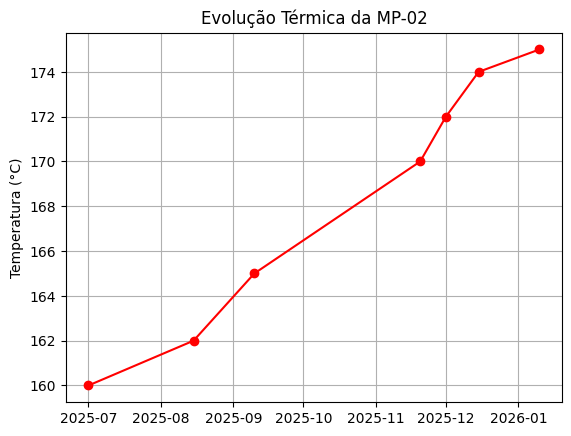

In [ ]:
import matplotlib.pyplot as plt

# 1. Criando a variável historico_mp02 a partir do seu df_maquinas
# Filtramos a linha do id 2 e pegamos o conteúdo da coluna 'historico'
mp02_dados_brutos = df_maquinas[df_maquinas['id'] == 2]['historico'].values[0]
historico_mp02 = pd.DataFrame(mp02_dados_brutos)

# 2. O seu código do gráfico (exatamente como você quer)
historico_mp02['data'] = pd.to_datetime(historico_mp02['data'])

plt.plot(historico_mp02['data'], historico_mp02['temp'], marker='o', color='red')
plt.title('Evolução Térmica da MP-02')
plt.ylabel('Temperatura (°C)')
plt.grid(True)

plt.show()


In [ ]:
# Acessando a contabilidade
df_contabilidade = pd.read_json('/content/dados_contabilidade.json')
print(df_contabilidade)

        nf               forn     item    qtd      total    status  \
0  NF-4020  Reflorestadora PR  Madeira  15000   R$ 7.500  Faturado   
1  NF-4100        Química Sul     Soda  10000  R$ 50.000  Faturado   
2  NF-5003        Química Sul   Resina   8000  R$ 40.000  Faturado   
3  NF-5004        Química Sul   Resina   8000  R$ 40.000  Faturado   

                              dados  
0  [{'k': 'Data', 'v': '10/07/25'}]  
1  [{'k': 'Data', 'v': '05/08/25'}]  
2  [{'k': 'Data', 'v': '11/01/26'}]  
3  [{'k': 'Data', 'v': '12/01/26'}]  


In [ ]:
df_contabilidade.head()

,nf,forn,item,qtd,total,status,dados
0,NF-4020,Reflorestadora PR,Madeira,15000,R$ 7.500,Faturado,"[{'k': 'Data', 'v': '10/07/25'}]"
1,NF-4100,Química Sul,Soda,10000,R$ 50.000,Faturado,"[{'k': 'Data', 'v': '05/08/25'}]"
2,NF-5003,Química Sul,Resina,8000,R$ 40.000,Faturado,"[{'k': 'Data', 'v': '11/01/26'}]"
3,NF-5004,Química Sul,Resina,8000,R$ 40.000,Faturado,"[{'k': 'Data', 'v': '12/01/26'}]"


In [ ]:
df_balanca.head()

,nf,peso_entrada,peso_saida,peso_liquido
0,NF-5003,18200,10200,8000
1,NF-5004,18150,10150,8000


In [ ]:

# Extrair a data de dentro da coluna 'dados'
df_contabilidade['data'] = df_contabilidade['dados'].apply(
    lambda x: x[0]['v']
)
df_filtrado = df_contabilidade[
    (df_contabilidade['forn'] == 'Química Sul') &
    (df_contabilidade['data'].isin(['11/01/26', '12/01/26']))
][['nf', 'forn', 'data', 'qtd', 'status']]

display(df_filtrado)

,nf,forn,data,qtd,status
2,NF-5003,Química Sul,11/01/26,8000,Faturado
3,NF-5004,Química Sul,12/01/26,8000,Faturado


In [ ]:

df_balanca = pd.DataFrame({
    'nf': ['NF-5003', 'NF-5004'],
    'peso_entrada': [18200, 18150],
    'peso_saida': [10200, 10150]
})

In [ ]:
df_balanca['peso_liquido'] = (
    df_balanca['peso_entrada'] - df_balanca['peso_saida']
)

In [ ]:
df_conferencia = (
    df_filtrado
    .merge(
        df_balanca[['nf', 'peso_liquido']],
        on='nf',
        how='left'
    )
)

In [ ]:
df_conferencia['diferenca_kg'] = (
    df_conferencia['peso_liquido'] - df_conferencia['qtd']
)

display(df_conferencia)

,nf,forn,data,qtd,status,peso_liquido,diferenca_kg
0,NF-5003,Química Sul,11/01/26,8000,Faturado,8000,0
1,NF-5004,Química Sul,12/01/26,8000,Faturado,8000,0


In [ ]:
df_tanque_resina = pd.DataFrame({
    'tanque': ['R-01'],
    'nivel_atual_kg': [24000],
    'capacidade_kg': [30000]
})

In [ ]:
df_tanque_resina['ocupacao_%'] = (
    df_tanque_resina['nivel_atual_kg'] / df_tanque_resina['capacidade_kg'] * 100
)

df_tanque_resina['status'] = df_tanque_resina['ocupacao_%'].apply(
    lambda x: 'Crítico' if x > 90 else 'Alerta' if x > 75 else 'Normal'
)

In [ ]:
entrada_resina = df_conferencia['peso_liquido'].sum()

In [ ]:
print("Status do Tanque de Resina")
print("-" * 50)

for _, linha in df_tanque_resina.iterrows():
    print(f"Tanque: {linha['tanque']}")
    print(f"Nível Atual: {linha['nivel_atual_kg']:,.0f} kg")
    print(f"Capacidade: {linha['capacidade_kg']:,.0f} kg")
    print(f"Ocupação: {linha['ocupacao_%']:.1f}%")
    print(f"Status: {linha['status']}")

🛢️ Status do Tanque de Resina
--------------------------------------------------
Tanque: R-01
Nível Atual: 24,000 kg
Capacidade: 30,000 kg
Ocupação: 80.0%
Status: Alerta
